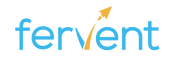
# Reducing Risk by Diversification - Number of Securities to Hold
In this walkthrough, you'll explore what the optimal number of securities might be.

In [1]:
# Import package dependencies
import pandas as pd  # for data management and analysis
import numpy as np  # for numerical computations
import matplotlib.pyplot as plt  # for plotting
import seaborn as sns  # for making charts look good
sns.set()  # implementing the seaborn plotting templates / themes

<div class="alert alert-block alert-info">
<b>Confused by any of the code in this notebook?</b>  

Go back to the lecture on Reducing Risk by Diversification to understand the code in this notebook, before moving on any further.
</div>


In [2]:
df = pd.read_csv('../data/15stocks_price.csv')  # stock price data

# Convert dates to timestamps and set date column as the index
df['date_gsheets'] = pd.to_datetime(df['date_gsheets'])
df.set_index('date_gsheets', inplace=True)

# Calculate returns for each stock
returns_df = df.pct_change(1)

In [3]:
# Estimating the risk of a 15 asset portfolio
num_stocks = 15
weights = [1 / num_stocks] * num_stocks  # vector (list) of weights
vcv_matrix = returns_df.cov()  # variance covariance matrix

# Calculate variance and standard deviation of the 10 asset portfolio
var_portfolio = np.dot(np.transpose(weights), np.dot(vcv_matrix, weights))
sd_portfolio = np.sqrt(var_portfolio)
sd_portfolio_annual = sd_portfolio * np.sqrt(250)

# Estimate individual stock risks for comparison
individual_risks = np.std(returns_df) * np.sqrt(250)

In [4]:
returns_df.head()

,AAPL,KO,NFLX,BRK.B,DIS,IBM,VZ,WMT,GE,TSLA,MA,AMZN,MSFT,UN,V
date_gsheets,,,,,,,,,,,,,,,
2012-01-03 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-01-04 16:00:00,0.005277,-0.006273,0.113372,-0.011329,0.014096,-0.004079,-0.013088,-0.010277,0.010893,-0.013177,-0.032845,-0.008490,0.023534,-0.013459,-0.017864
2012-01-05 16:00:00,0.011175,-0.004591,-0.013925,0.001693,0.016731,-0.004743,-0.006886,-0.004857,-0.000539,-0.021292,-0.010946,0.000563,0.010219,0.001161,0.007513
2012-01-06 16:00:00,0.010382,-0.006342,0.088261,-0.007019,0.010380,-0.011481,-0.015665,-0.007068,0.005391,-0.007743,-0.026958,0.028152,0.015535,-0.035373,-0.011774
2012-01-09 16:00:00,-0.001492,0.000000,0.137875,-0.001309,-0.004009,-0.005204,0.001044,0.003051,0.011260,0.012635,0.008457,-0.022178,-0.013163,0.013526,-0.007943


In [5]:
tickers = list(returns_df.columns)
portfolios = []

for i in range(1, len(tickers) + 1):
    portfolios.append(tickers[0:i])

In [6]:
# Calculate the risk of each portfolio
portfolio_risks = []

for port in portfolios:
    df = returns_df[port]
    
    num_stocks = len(df.columns)
    weights = [1 / num_stocks] * num_stocks
    vcv_p = df.cov()
    
    var_p = np.dot(np.transpose(weights), np.dot(vcv_p, weights))
    sd_p = np.sqrt(var_p)
    sd_p_annual = sd_p * np.sqrt(250)
    
    portfolio_risks.append(sd_p_annual)

In [7]:
risks_df = pd.DataFrame(portfolio_risks)

In [8]:
risks_df.rename(columns={risks_df.columns[0] : 'total_risk'}, inplace=True)

In [9]:
risks_df.reset_index(inplace=True)
risks_df.rename(columns={'index' : 'num_securities'}, inplace=True)
risks_df['num_securities'] += 1
risks_df.set_index('num_securities', inplace=True)

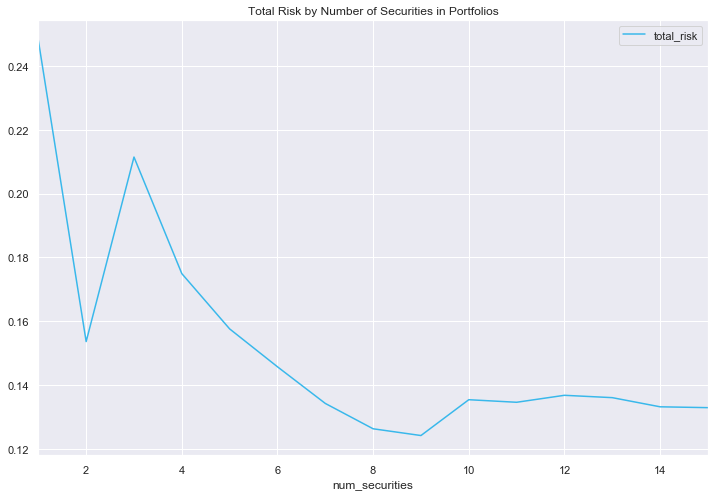

In [10]:
risks_df.plot(figsize=(12, 8), color='#39b8eb', title='Total Risk by Number of Securities in Portfolios')

In [11]:
risks_df

,total_risk
num_securities,
1,0.248085
2,0.153617
3,0.211457
4,0.174917
5,0.157592
6,0.145713
7,0.134229
8,0.126281
9,0.124166


## Bonus: Better Plotting
We can improve the plot by showing percentages on the y axis (instead of decimal numericals). Furthermore, we can improve the color scheme of the line, including highlighting each portfolio with a circle. And of course, we can improve the title by increasing the fontsize.

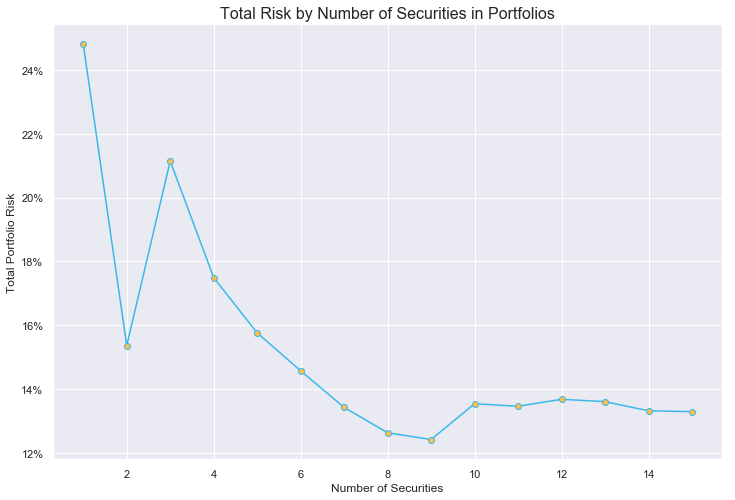

In [12]:
plt.figure(figsize=(12, 8))
plt.title('Total Risk by Number of Securities in Portfolios', fontsize=16)
plt.plot(risks_df, marker='o', color='#39b8eb', markerfacecolor='#ffbd4a')
plt.xlabel('Number of Securities')
plt.ylabel('Total Portfolio Risk')
plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])
plt.savefig('reducingRisk_byDiversification_plot.png')